This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [79]:
!pip install keras keras-hub --upgrade -q

In [3]:

import os
os.environ["KERAS_BACKEND"] = "jax"

In [81]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [4]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

In [83]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [84]:
train_labels[0]

np.int64(1)

In [85]:
max([max(sequence) for sequence in train_data])

9999

In [86]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

In [87]:
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [9]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [10]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [11]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [12]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

In [14]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [15]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.7799 - loss: 0.5522 - val_accuracy: 0.8536 - val_loss: 0.4076
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8961 - loss: 0.3067 - val_accuracy: 0.8868 - val_loss: 0.2972
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9329 - loss: 0.2047 - val_accuracy: 0.8884 - val_loss: 0.2785
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9513 - loss: 0.1545 - val_accuracy: 0.8870 - val_loss: 0.2839
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9674 - loss: 0.1187 - val_accuracy: 0.8837 - val_loss: 0.2935
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9765 - loss: 0.0934 - val_accuracy: 0.8808 - val_loss: 0.3111
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9838 - loss: 0.0732 - val_accuracy: 0.8803 - val_loss: 0.3335
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9896 - loss: 0.0564 - val_accuracy: 0.8782 - v

In [16]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9273 - loss: 0.2842 - val_accuracy: 0.9704 - val_loss: 0.0835
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9589 - loss: 0.1273 - val_accuracy: 0.9690 - val_loss: 0.0881
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9790 - loss: 0.0771 - val_accuracy: 0.9630 - val_loss: 0.0969
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9879 - loss: 0.0530 - val_accuracy: 0.9576 - val_loss: 0.1126
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9936 - loss: 0.0392 - val_accuracy: 0.9550 - val_loss: 0.1260
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9960 - loss: 0.0305 - val_accuracy: 0.9498 - val_loss: 0.1443
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9974 - loss: 0.0240 - val_accuracy: 0.9470 - val_loss: 0.1619
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9981 - loss: 0.0192 - val_accuracy: 0.9460 - v

In [17]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

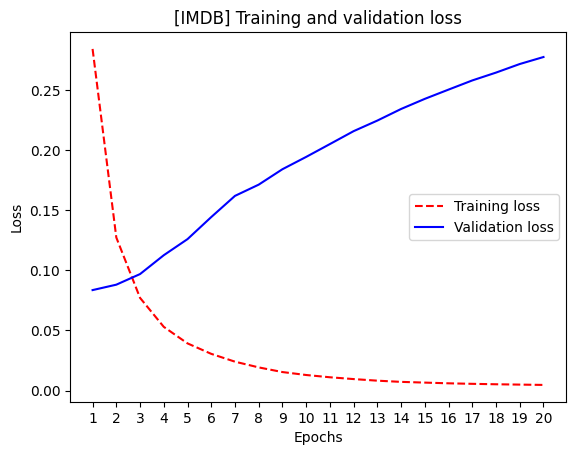

In [18]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

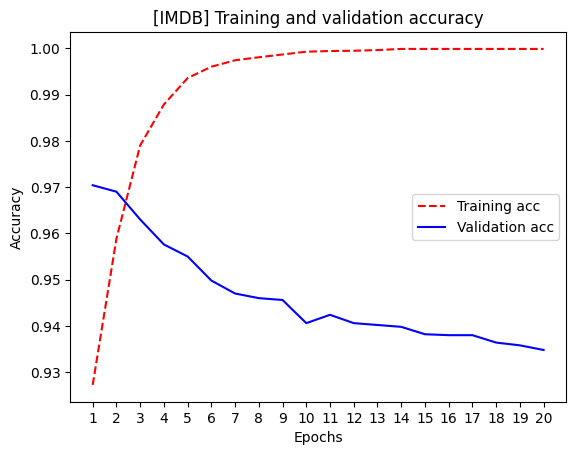

In [19]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
model_1layer = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_1layer.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_1layer = model_1layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7601 - loss: 0.5511 - val_accuracy: 0.8591 - val_loss: 0.4176
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8965 - loss: 0.3330 - val_accuracy: 0.8808 - val_loss: 0.3276
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9214 - loss: 0.2506 - val_accuracy: 0.8872 - val_loss: 0.2950
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9381 - loss: 0.2044 - val_accuracy: 0.8882 - val_loss: 0.2823
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9493 - loss: 0.1730 - val_accuracy: 0.8880 - val_loss: 0.2775
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9581 - loss: 0.1485 - val_accuracy: 0.8866 - val_loss: 0.2801
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9653 - loss: 0.1294 - val_accuracy: 0.8857 - val_loss: 0.2825
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9715 - loss: 0.1127 - val_accuracy: 0.8842 - v

In [21]:
history_1layer.history["val_loss"]
history_1layer.history["val_accuracy"]

[0.8591000437736511,
 0.8808000683784485,
 0.8872000575065613,
 0.888200044631958,
 0.8880000710487366,
 0.8866000175476074,
 0.8857000470161438,
 0.8842000365257263,
 0.883400022983551,
 0.8812000155448914,
 0.879300057888031,
 0.879800021648407,
 0.8785000443458557,
 0.8772000670433044,
 0.8776000142097473,
 0.8744000196456909,
 0.8755000233650208,
 0.8732000589370728,
 0.8739000558853149,
 0.8711000680923462]

In [22]:
model_3layers = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_3layers.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_3layers = model_3layers.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7614 - loss: 0.5774 - val_accuracy: 0.8559 - val_loss: 0.4183
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8939 - loss: 0.3050 - val_accuracy: 0.8861 - val_loss: 0.2909
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9326 - loss: 0.1930 - val_accuracy: 0.8885 - val_loss: 0.2772
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9577 - loss: 0.1343 - val_accuracy: 0.8871 - val_loss: 0.2914
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9725 - loss: 0.0952 - val_accuracy: 0.8820 - val_loss: 0.3305
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9829 - loss: 0.0671 - val_accuracy: 0.8807 - val_loss: 0.3655
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9904 - loss: 0.0451 - val_accuracy: 0.8781 - val_loss: 0.4043
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9966 - loss: 0.0260 - val_accuracy: 0.8754 - v

In [23]:
history_3layers.history["val_loss"]
history_3layers.history["val_accuracy"]

[0.8559000492095947,
 0.8861000537872314,
 0.8885000348091125,
 0.8871000409126282,
 0.8820000290870667,
 0.8807000517845154,
 0.8781000375747681,
 0.8754000663757324,
 0.8739000558853149,
 0.8713000416755676,
 0.8706000447273254,
 0.8711000680923462,
 0.8708000183105469,
 0.8705000281333923,
 0.8698000311851501,
 0.8699000477790833,
 0.8693000674247742,
 0.8698000311851501,
 0.8696000576019287,
 0.869700014591217]

In [24]:
model_8units = keras.Sequential(
    [
        layers.Dense(8, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_8units.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_8units = model_8units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7449 - loss: 0.6385 - val_accuracy: 0.8370 - val_loss: 0.5608
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8732 - loss: 0.4779 - val_accuracy: 0.8665 - val_loss: 0.4278
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8998 - loss: 0.3517 - val_accuracy: 0.8775 - val_loss: 0.3471
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9178 - loss: 0.2716 - val_accuracy: 0.8847 - val_loss: 0.3061
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9321 - loss: 0.2193 - val_accuracy: 0.8905 - val_loss: 0.2851
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9429 - loss: 0.1831 - val_accuracy: 0.8903 - val_loss: 0.2764
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9538 - loss: 0.1546 - val_accuracy: 0.8903 - val_loss: 0.2767
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9629 - loss: 0.1322 - val_accuracy: 0.8876 - v

In [25]:
model_32units = keras.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_32units.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_32units = model_32units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.7900 - loss: 0.4877 - val_accuracy: 0.8772 - val_loss: 0.3156
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9177 - loss: 0.2279 - val_accuracy: 0.8822 - val_loss: 0.2915
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9506 - loss: 0.1473 - val_accuracy: 0.8856 - val_loss: 0.2873
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9715 - loss: 0.0996 - val_accuracy: 0.8829 - val_loss: 0.3139
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9852 - loss: 0.0673 - val_accuracy: 0.8777 - val_loss: 0.3496
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9915 - loss: 0.0458 - val_accuracy: 0.8747 - val_loss: 0.3897
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9960 - loss: 0.0303 - val_accuracy: 0.8744 - val_loss: 0.4339
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9986 - loss: 0.0198 - val_accuracy: 0.8733 - 

In [26]:
history_8units.history["val_accuracy"]
history_32units.history["val_accuracy"]

[0.8772000670433044,
 0.8822000622749329,
 0.8856000304222107,
 0.882900059223175,
 0.8777000308036804,
 0.8747000694274902,
 0.8744000196456909,
 0.8733000159263611,
 0.8723000288009644,
 0.8707000613212585,
 0.8694000244140625,
 0.8694000244140625,
 0.8694000244140625,
 0.8689000606536865,
 0.8678000569343567,
 0.8689000606536865,
 0.8680000305175781,
 0.8678000569343567,
 0.8677000403404236,
 0.867900013923645]

In [27]:
model_mse = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_mse.compile(
    optimizer="adam",
    loss="mse",
    metrics=["accuracy"],
)

history_mse = model_mse.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.7615 - loss: 0.1956 - val_accuracy: 0.8561 - val_loss: 0.1337
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8993 - loss: 0.0961 - val_accuracy: 0.8864 - val_loss: 0.0935
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9327 - loss: 0.0624 - val_accuracy: 0.8903 - val_loss: 0.0848
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9527 - loss: 0.0460 - val_accuracy: 0.8870 - val_loss: 0.0832
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9672 - loss: 0.0355 - val_accuracy: 0.8846 - val_loss: 0.0845
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9773 - loss: 0.0274 - val_accuracy: 0.8815 - val_loss: 0.0860
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9837 - loss: 0.0212 - val_accuracy: 0.8804 - val_loss: 0.0880
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9881 - loss: 0.0167 - val_accuracy: 0.8782 - v

In [28]:
model_tanh = keras.Sequential(
    [
        layers.Dense(16, activation="tanh"),
        layers.Dense(16, activation="tanh"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_tanh.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_tanh = model_tanh.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.7871 - loss: 0.5208 - val_accuracy: 0.8587 - val_loss: 0.3911
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9001 - loss: 0.2979 - val_accuracy: 0.8866 - val_loss: 0.2990
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9333 - loss: 0.2053 - val_accuracy: 0.8898 - val_loss: 0.2742
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9556 - loss: 0.1482 - val_accuracy: 0.8869 - val_loss: 0.2772
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9712 - loss: 0.1099 - val_accuracy: 0.8841 - val_loss: 0.2912
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9819 - loss: 0.0821 - val_accuracy: 0.8781 - val_loss: 0.3147
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9889 - loss: 0.0603 - val_accuracy: 0.8765 - val_loss: 0.3389
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9935 - loss: 0.0444 - val_accuracy: 0.8750 - 

In [29]:
model_logistic = keras.Sequential(
    [
        layers.Dense(1, activation="sigmoid"),
    ]
)

model_logistic.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_logistic = model_logistic.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.7230 - loss: 0.6308 - val_accuracy: 0.8012 - val_loss: 0.5764
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8408 - loss: 0.5285 - val_accuracy: 0.8320 - val_loss: 0.5090
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8636 - loss: 0.4663 - val_accuracy: 0.8470 - val_loss: 0.4652
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8773 - loss: 0.4227 - val_accuracy: 0.8562 - val_loss: 0.4328
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8891 - loss: 0.3895 - val_accuracy: 0.8640 - val_loss: 0.4087
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8988 - loss: 0.3632 - val_accuracy: 0.8683 - val_loss: 0.3898
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9038 - loss: 0.3420 - val_accuracy: 0.8727 - val_loss: 0.3746
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9101 - loss: 0.3236 - val_accuracy: 0.8758 - v

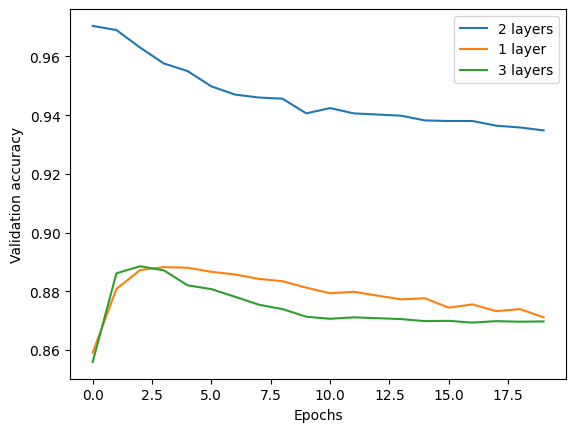

In [30]:
plt.plot(
    history.history["val_accuracy"],
    label="2 layers"
)

plt.plot(
    history_1layer.history["val_accuracy"],
    label="1 layer"
)

plt.plot(
    history_3layers.history["val_accuracy"],
    label="3 layers"
)

plt.xlabel("Epochs")
plt.ylabel("Validation accuracy")
plt.legend()
plt.show()

In [31]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8051 - loss: 0.4825
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9121 - loss: 0.2474
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9351 - loss: 0.1835
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9514 - loss: 0.1445
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8789 - loss: 0.3110


In [32]:
results

[0.31097182631492615, 0.8789199590682983]

#### Using a trained model to generate predictions on new data

In [33]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.1517896 ],
       [0.99978244],
       [0.55855864],
       ...,
       [0.07545364],
       [0.04610385],
       [0.5799929 ]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [34]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [35]:
len(train_data)

8982

In [36]:
len(test_data)

2246

In [37]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [38]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

In [39]:
train_labels[10]

np.int64(3)

#### Preparing the data

In [40]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [41]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [42]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

In [43]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

In [44]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

In [45]:
model_sparse = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model_sparse.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

x_val_sparse = x_train[:1000]
partial_x_train_sparse = x_train[1000:]

y_val_sparse = y_train[:1000]
partial_y_train_sparse = y_train[1000:]

history_sparse = model_sparse.fit(
    partial_x_train_sparse,
    partial_y_train_sparse,
    epochs=20,
    batch_size=512,
    validation_data=(x_val_sparse, y_val_sparse),
)

ValueError: Arguments `target` and `output` must have the same shape up until the last dimension: target.shape=(512, 46), output.shape=(512, 46)

#### Validating your approach

In [46]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [47]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.3641 - loss: 3.3131 - top_3_accuracy: 0.5509 - val_accuracy: 0.5270 - val_loss: 2.6027 - val_top_3_accuracy: 0.7360
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6240 - loss: 2.0566 - top_3_accuracy: 0.7666 - val_accuracy: 0.6560 - val_loss: 1.7009 - val_top_3_accuracy: 0.7690
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7108 - loss: 1.3973 - top_3_accuracy: 0.8021 - val_accuracy: 0.7020 - val_loss: 1.3289 - val_top_3_accuracy: 0.8030
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7658 - loss: 1.0770 - top_3_accuracy: 0.8566 - val_accuracy: 0.7560 - val_loss: 1.1574 - val_top_3_accuracy: 0.8450
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8192 - loss: 0.8539 - top_3_accuracy: 0.9042 - val_accuracy: 0.7810 - val_loss: 1.0601 - val_top_3_accuracy: 0.8790
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8616 - loss: 0.6741 - top_3_a

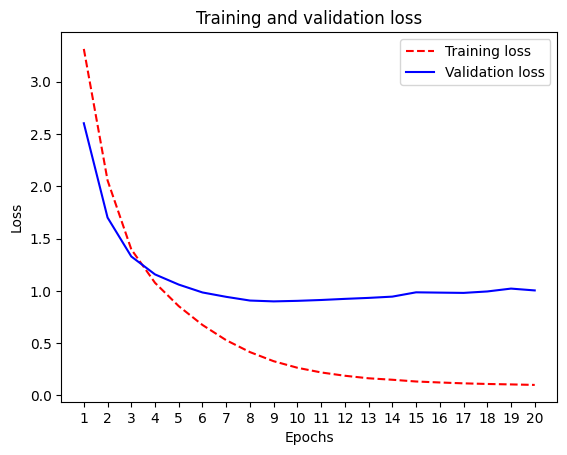

In [48]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

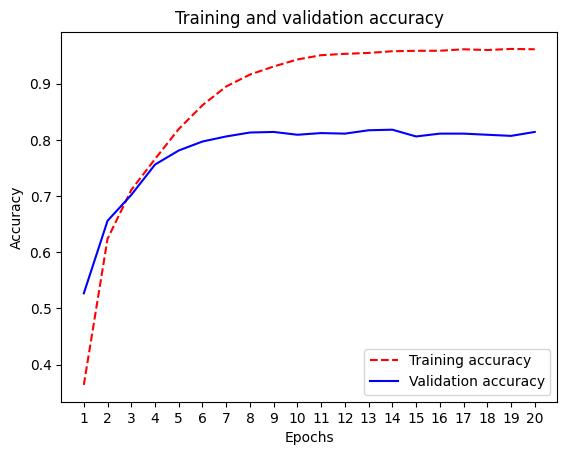

In [49]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

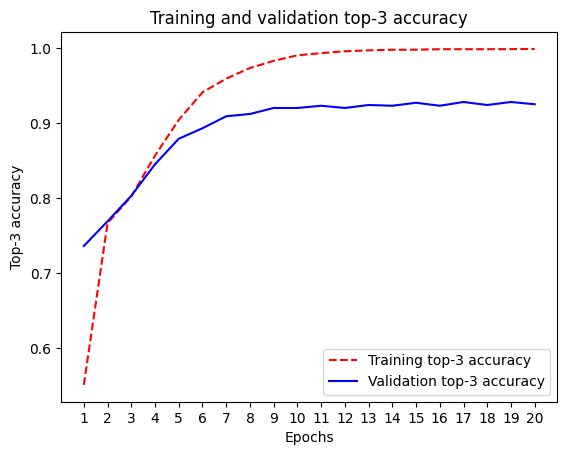

In [50]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [51]:
model_1layer = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model_1layer.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_1layer = model_1layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.4759 - loss: 3.1666 - val_accuracy: 0.5750 - val_loss: 2.3910
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6495 - loss: 1.8967 - val_accuracy: 0.6670 - val_loss: 1.6151
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7368 - loss: 1.3156 - val_accuracy: 0.7280 - val_loss: 1.2852
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7993 - loss: 1.0112 - val_accuracy: 0.7790 - val_loss: 1.1148
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8390 - loss: 0.8095 - val_accuracy: 0.7940 - val_loss: 1.0149
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8700 - loss: 0.6636 - val_accuracy: 0.8060 - val_loss: 0.9505
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8923 - loss: 0.5519 - val_accuracy: 0.8170 - val_loss: 0.9023
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9109 - loss: 0.4606 - val_accuracy: 0.8230 - 

In [52]:
model_3layers = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model_3layers.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_3layers = model_3layers.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.3400 - loss: 3.2575 - val_accuracy: 0.4480 - val_loss: 2.3930
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5699 - loss: 1.9231 - val_accuracy: 0.6490 - val_loss: 1.6014
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7025 - loss: 1.3900 - val_accuracy: 0.7140 - val_loss: 1.3164
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7568 - loss: 1.0899 - val_accuracy: 0.7480 - val_loss: 1.1576
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8066 - loss: 0.8564 - val_accuracy: 0.7720 - val_loss: 1.0730
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8534 - loss: 0.6590 - val_accuracy: 0.7860 - val_loss: 1.0099
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8916 - loss: 0.4881 - val_accuracy: 0.8010 - val_loss: 0.9653
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9236 - loss: 0.3589 - val_accuracy: 0.8050 - 

In [53]:
model_32units = keras.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model_32units.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_32units = model_32units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.1119 - loss: 3.6677 - val_accuracy: 0.3890 - val_loss: 3.3530
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5496 - loss: 2.9354 - val_accuracy: 0.6090 - val_loss: 2.4636
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6501 - loss: 1.9875 - val_accuracy: 0.6420 - val_loss: 1.7200
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7081 - loss: 1.4377 - val_accuracy: 0.6920 - val_loss: 1.4084
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7508 - loss: 1.1835 - val_accuracy: 0.7180 - val_loss: 1.2715
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7745 - loss: 1.0173 - val_accuracy: 0.7420 - val_loss: 1.1917
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8034 - loss: 0.8833 - val_accuracy: 0.7550 - val_loss: 1.1314
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8304 - loss: 0.7655 - val_accuracy: 0.7630 - 

In [54]:
model_128units = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

model_128units.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_128units = model_128units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.4539 - loss: 3.0089 - val_accuracy: 0.5750 - val_loss: 2.0389
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6719 - loss: 1.5672 - val_accuracy: 0.7010 - val_loss: 1.3503
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7652 - loss: 1.0653 - val_accuracy: 0.7570 - val_loss: 1.1148
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8292 - loss: 0.7697 - val_accuracy: 0.7910 - val_loss: 0.9835
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8872 - loss: 0.5400 - val_accuracy: 0.8130 - val_loss: 0.9137
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9173 - loss: 0.3792 - val_accuracy: 0.8200 - val_loss: 0.8951
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9400 - loss: 0.2730 - val_accuracy: 0.8160 - val_loss: 0.8794
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9501 - loss: 0.2082 - val_accuracy: 0.8160 - 

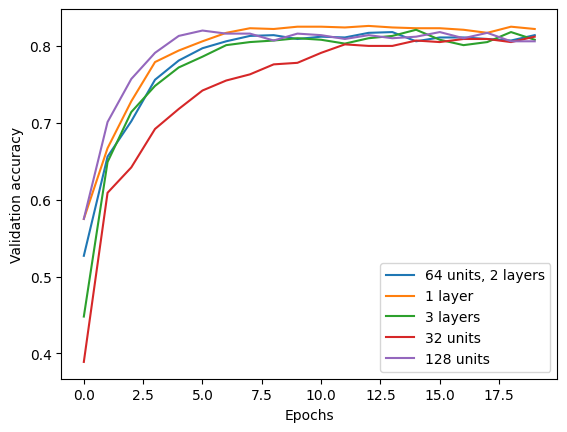

In [55]:
plt.plot(
    history.history["val_accuracy"],
    label="64 units, 2 layers"
)

plt.plot(
    history_1layer.history["val_accuracy"],
    label="1 layer"
)

plt.plot(
    history_3layers.history["val_accuracy"],
    label="3 layers"
)

plt.plot(
    history_32units.history["val_accuracy"],
    label="32 units"
)

plt.plot(
    history_128units.history["val_accuracy"],
    label="128 units"
)

plt.xlabel("Epochs")
plt.ylabel("Validation accuracy")
plt.legend()
plt.show()

In [56]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.3416 - loss: 3.3497
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6442 - loss: 1.9251
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7375 - loss: 1.2458
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7975 - loss: 0.9427
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8458 - loss: 0.7320
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8845 - loss: 0.5661
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9077 - loss: 0.4360
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9279 - loss: 0.3394
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9408 - loss: 0.2699
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7979 - loss: 0.9193


In [57]:
results

[0.9192978739738464, 0.7978628873825073]

In [58]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.17497773820124665)

#### Generating predictions on new data

In [59]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [60]:
predictions[0].shape

(46,)

In [61]:
np.sum(predictions[0])

np.float32(1.0000001)

In [62]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [63]:
y_train = train_labels
y_test = test_labels

In [64]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [65]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2372 - loss: 3.0316 - val_accuracy: 0.5370 - val_loss: 2.2748
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6258 - loss: 1.7271 - val_accuracy: 0.6560 - val_loss: 1.5078
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7120 - loss: 1.2517 - val_accuracy: 0.6920 - val_loss: 1.3710
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7493 - loss: 1.0615 - val_accuracy: 0.6950 - val_loss: 1.3248
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7633 - loss: 0.9444 - val_accuracy: 0.7050 - val_loss: 1.3009
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7813 - loss: 0.8554 - val_accuracy: 0.7090 - val_loss: 1.3068
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7939 - loss: 0.7760 - val_accuracy: 0.7140 - val_loss: 1.3022
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8104 - loss: 0.7157 - val_accuracy: 0.7140 - val_loss

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [66]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

In [67]:
train_data.shape

(480, 8)

In [68]:
test_data.shape

(120, 8)

In [69]:
train_targets

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

In [70]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [71]:
y_train = train_targets / 100000
y_test = test_targets / 100000

#### Building your model

In [72]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

In [73]:
def get_model_32():
    model = keras.Sequential(
        [
            layers.Dense(32, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )

    return model

In [74]:
def get_model_32():
    model = keras.Sequential(
        [
            layers.Dense(32, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )

    return model

In [75]:
def get_model_1layer():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )

    return model

In [76]:
def get_model_1layer():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )

    return model

#### Validating your approach using K-fold validation

In [77]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [78]:
[round(value, 3) for value in all_scores]

[0.296, 0.287, 0.238, 0.318]

In [79]:
round(np.mean(all_scores), 3)

np.float64(0.285)

In [80]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [81]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

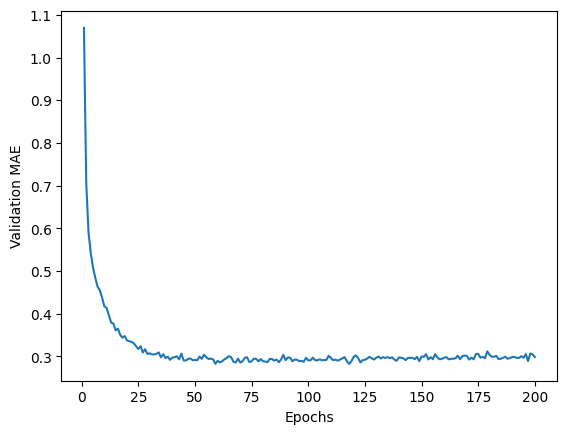

In [82]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

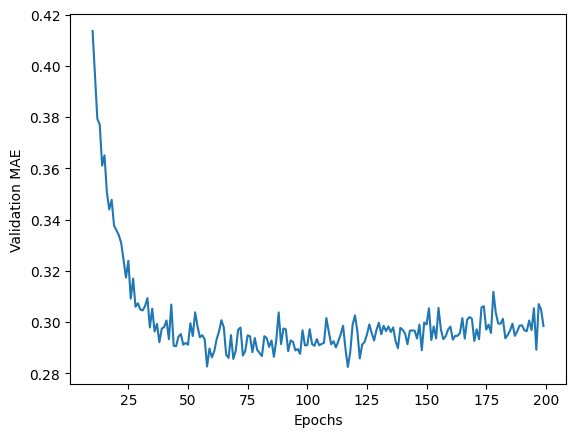

In [83]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [84]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2776 - mean_absolute_error: 0.3154


In [85]:
round(test_mean_absolute_error, 3)

0.315

In [86]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories_32 = []

for i in range(k):
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]

    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples],
         x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )

    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples],
         y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )

    model = get_model_32()

    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )

    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories_32.append(mae_history)

In [87]:
average_mae_history_32 = [
    np.mean([x[i] for x in all_mae_histories_32])
    for i in range(num_epochs)
]

#### Generating predictions on new data

In [88]:
predictions = model.predict(x_test)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([2.2058792], dtype=float32)

#### Wrapping up